# Collaborative Filtering from Scratch

**Core idea**: users who agreed in the past will agree in the future.
No item metadata — just the pattern of who liked what.

We implement two flavors:
1. **User-User CF**: find users similar to you → borrow their ratings
2. **Item-Item CF**: find items similar to what you liked → recommend those

Everything is written from scratch in NumPy so the mechanics are fully visible.

## 1. Load and Explore the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

DATA_DIR = Path("../data/ml-100k")

ratings = pd.read_csv(
    DATA_DIR / "u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"],
)

movies = pd.read_csv(
    DATA_DIR / "u.item",
    sep="|",
    encoding="latin-1",
    names=["item_id", "title", "release_date", "video_date", "imdb_url"] + [f"genre_{i}" for i in range(19)],
    usecols=["item_id", "title"],
)

print(f"Ratings: {len(ratings):,}")
print(f"Users:   {ratings['user_id'].nunique()}")
print(f"Items:   {ratings['item_id'].nunique()}")
print(f"Rating range: {ratings['rating'].min()}–{ratings['rating'].max()}")
ratings.head()

Ratings: 100,000
Users:   943
Items:   1682
Rating range: 1–5


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


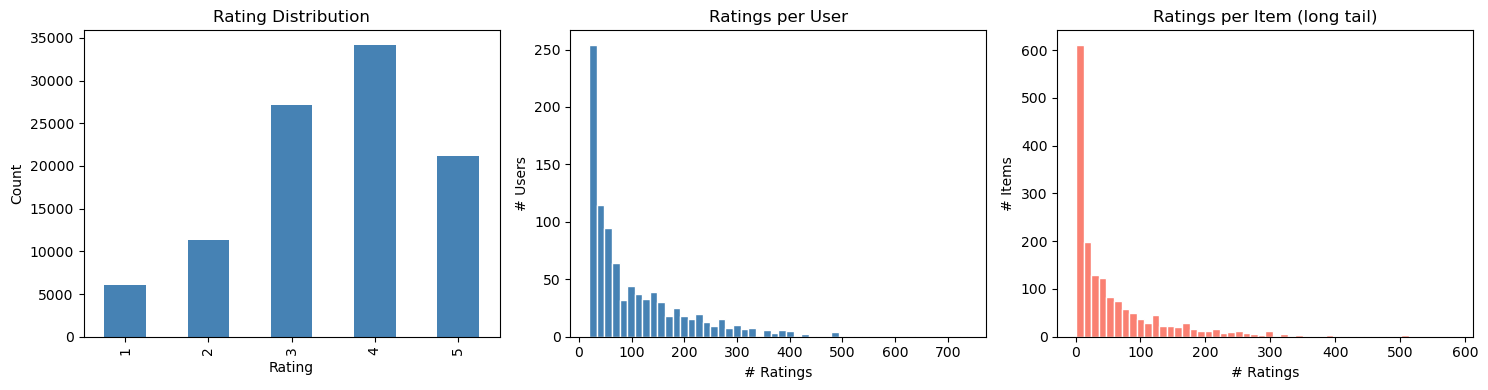

Sparsity: 93.7% of the matrix is empty
Median ratings per user: 65
Median ratings per item: 27


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

ratings_per_user = ratings.groupby('user_id').size()
axes[1].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('# Ratings')
axes[1].set_ylabel('# Users')

ratings_per_item = ratings.groupby('item_id').size()
axes[2].hist(ratings_per_item, bins=50, color='salmon', edgecolor='white')
axes[2].set_title('Ratings per Item (long tail)')
axes[2].set_xlabel('# Ratings')
axes[2].set_ylabel('# Items')

plt.tight_layout()
plt.show()

n_users = ratings['user_id'].nunique()
n_items = ratings['item_id'].nunique()
print(f"Sparsity: {1 - len(ratings) / (n_users * n_items):.1%} of the matrix is empty")
print(f"Median ratings per user: {ratings_per_user.median():.0f}")
print(f"Median ratings per item: {ratings_per_item.median():.0f}")

## 2. Train/Test Split

**Leave-one-out**: for each user, hold out their most recent rating as the test item.
The model must rank that item highly among all items the user hasn't seen in training.

This mirrors the real task: given a user's history, what should we show next?

In [3]:
ratings_sorted = ratings.sort_values(['user_id', 'timestamp'])
test = ratings_sorted.groupby('user_id').tail(1).copy()
train = ratings_sorted.drop(test.index).copy()

print(f"Train: {len(train):,} ratings")
print(f"Test:  {len(test):,} ratings (1 per user)")

# 0-based index mappings for matrix operations
user_ids = sorted(ratings['user_id'].unique())
item_ids = sorted(ratings['item_id'].unique())
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {it: i for i, it in enumerate(item_ids)}
idx2item = {i: it for it, i in item2idx.items()}

N_USERS = len(user_ids)
N_ITEMS = len(item_ids)
print(f"\nMatrix shape: {N_USERS} users × {N_ITEMS} items")

Train: 99,057 ratings
Test:  943 ratings (1 per user)

Matrix shape: 943 users × 1682 items


In [4]:
# Build the user-item rating matrix (dense, float32)
R = np.zeros((N_USERS, N_ITEMS), dtype=np.float32)
for row in train.itertuples():
    R[user2idx[row.user_id], item2idx[row.item_id]] = row.rating

print(f"Rating matrix R: {R.shape}")
print(f"Non-zero entries: {(R > 0).sum():,}")
print(f"Density: {(R > 0).mean():.2%}")

Rating matrix R: (943, 1682)
Non-zero entries: 99,057
Density: 6.25%


## 3. Cosine Similarity

The building block for both approaches. Between two row vectors $a$ and $b$:

$$\text{sim}(a, b) = \frac{a \cdot b}{\|a\| \cdot \|b\|}$$

If we L2-normalize each row first, the full similarity matrix is just a matrix multiply:
$$S = \hat{M} \hat{M}^T$$

This gives us pairwise similarity between every pair of rows in one vectorized operation.

In [5]:
def cosine_similarity_matrix(M: np.ndarray) -> np.ndarray:
    """
    Pairwise cosine similarity between all rows of M.
    Zeros are treated as missing (not as a 0-rating), which matters for
    the norm: we normalize by the magnitude of observed entries only.
    """
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1e-10
    M_normed = M / norms
    return M_normed @ M_normed.T  # (n x n)


print("Computing user-user similarity matrix...")
t0 = time.time()
user_sim = cosine_similarity_matrix(R)
np.fill_diagonal(user_sim, 0)  # users shouldn't count themselves as neighbors
print(f"  Done in {time.time()-t0:.2f}s — shape {user_sim.shape}")

print("\nComputing item-item similarity matrix...")
t0 = time.time()
item_sim = cosine_similarity_matrix(R.T)  # rows = items
np.fill_diagonal(item_sim, 0)
print(f"  Done in {time.time()-t0:.2f}s — shape {item_sim.shape}")

Computing user-user similarity matrix...
  Done in 0.00s — shape (943, 943)

Computing item-item similarity matrix...
  Done in 0.01s — shape (1682, 1682)


## 4. User-User CF: Score All Items at Once

For user $u$ and item $i$, using mean-centered ratings:

$$\hat{r}_{ui} = \bar{r}_u + \frac{\sum_{v \in N_K(u)} \text{sim}(u,v) \cdot (r_{vi} - \bar{r}_v)}{\sum_{v \in N_K(u)} |\text{sim}(u,v)|}$$

Instead of calling this once per item, we compute scores for **all items simultaneously** as a matrix operation — this is what makes it fast enough to evaluate.

In [6]:
# Precompute per-user mean ratings (over rated items only)
rated_mask = R > 0
n_rated = rated_mask.sum(axis=1)  # (N_USERS,)
user_means = np.where(n_rated > 0, R.sum(axis=1) / np.maximum(n_rated, 1), 0)  # (N_USERS,)

# Mean-centered rating matrix: only subtract mean where item was rated
R_centered = np.where(rated_mask, R - user_means[:, np.newaxis], 0)  # (N_USERS, N_ITEMS)

print(f"User means — min: {user_means.min():.2f}, mean: {user_means.mean():.2f}, max: {user_means.max():.2f}")

User means — min: 1.49, mean: 3.59, max: 4.86


In [7]:
def user_user_scores(user_idx: int, K: int = 30) -> np.ndarray:
    """
    Return a predicted score for every item for the given user.
    Vectorized: all N_ITEMS scores computed in one matrix multiply.
    """
    sims = user_sim[user_idx].copy()  # (N_USERS,)

    # Keep only top-K neighbors
    top_k = np.argpartition(sims, -K)[-K:]
    mask = np.zeros(N_USERS, dtype=bool)
    mask[top_k] = True
    sims = np.where(mask & (sims > 0), sims, 0)

    sim_sum = np.abs(sims).sum() + 1e-10  # scalar denominator

    # Weighted sum of centered ratings across all items: (N_USERS,) @ (N_USERS, N_ITEMS)
    weighted = sims @ R_centered  # (N_ITEMS,)
    scores = user_means[user_idx] + weighted / sim_sum
    return np.clip(scores, 1, 5)


# Sanity check
scores = user_user_scores(0, K=30)
print(f"Scores for user 0 — shape: {scores.shape}, min: {scores.min():.2f}, max: {scores.max():.2f}")
top5 = np.argsort(scores)[::-1][:5]
print("Top 5 predicted items for user 0 (unrated items would be filtered at serve time):")
for idx in top5:
    item_id = idx2item[idx]
    title = movies.loc[movies['item_id'] == item_id, 'title'].values[0]
    print(f"  {title} (score={scores[idx]:.3f}, in-train-rating={R[0, idx]:.0f})")

Scores for user 0 — shape: (1682,), min: 3.04, max: 4.93
Top 5 predicted items for user 0 (unrated items would be filtered at serve time):
  Star Wars (1977) (score=4.930, in-train-rating=5)
  Raiders of the Lost Ark (1981) (score=4.863, in-train-rating=5)
  Princess Bride, The (1987) (score=4.787, in-train-rating=5)
  Pulp Fiction (1994) (score=4.718, in-train-rating=4)
  Usual Suspects, The (1995) (score=4.714, in-train-rating=5)


## 5. Item-Item CF: Score All Items at Once

For user $u$ and target item $i$:

$$\hat{r}_{ui} = \frac{\sum_{j \in N_K(i) \cap \text{rated}(u)} \text{sim}(i, j) \cdot r_{uj}}{\sum_{j \in N_K(i) \cap \text{rated}(u)} |\text{sim}(i, j)|}$$

**Sparsity trap**: the matrix is only 6% dense. For many (target item, user) pairs, the user has rated *none* of the K most similar items — the denominator is zero and the score collapses. With hundreds of items all tied at the same floor score, the test item gets buried in the noise.

Fix: when there's no neighbor evidence, fall back to a global item prior (here: item popularity). This is standard practice — CF only has an opinion where overlap exists.

In [8]:
# Precompute item priors: normalized popularity score in [1, 5]
# Used as fallback when CF has no neighbor evidence for a (user, item) pair
item_popularity = (R > 0).sum(axis=0).astype(np.float32)
pop_max = item_popularity.max()
item_prior = 1.0 + 4.0 * (item_popularity / pop_max)  # scale to [1, 5]


def item_item_scores(user_idx: int, K: int = 30) -> np.ndarray:
    """
    Return predicted score for every item for the given user.

    For each target item i, weight the user's ratings on the K most similar
    items they have actually rated. Fall back to item popularity prior where
    the user has no rated neighbors (the sparsity problem).
    """
    user_ratings = R[user_idx]          # (N_ITEMS,) — 0 = not rated
    rated = user_ratings > 0            # boolean mask

    # Zero out neighbor similarities where user hasn't rated that neighbor
    sim_masked = item_sim * rated[np.newaxis, :]   # (N_ITEMS, N_ITEMS)

    # Keep only top-K rated neighbors per target item
    threshold_idx = np.argpartition(sim_masked, -K, axis=1)[:, -K:]
    sim_topk = np.zeros_like(sim_masked)
    np.put_along_axis(
        sim_topk,
        threshold_idx,
        np.take_along_axis(sim_masked, threshold_idx, axis=1),
        axis=1,
    )

    numerator = sim_topk @ user_ratings           # (N_ITEMS,)
    denominator = sim_topk.sum(axis=1)            # (N_ITEMS,) — sum of positive sims only

    has_evidence = denominator > 0
    cf_scores = np.where(has_evidence, numerator / np.maximum(denominator, 1e-10), 0)

    # Blend: use CF score where we have evidence, item prior elsewhere
    scores = np.where(has_evidence, cf_scores, item_prior)
    return np.clip(scores, 1, 5)


scores_ii = item_item_scores(0, K=30)
n_cf = ((R[0] == 0) & (item_item_scores(0) != item_prior)).sum()
print(f"Item-Item scores for user 0 — shape: {scores_ii.shape}")
print(f"  min: {scores_ii.min():.2f}, max: {scores_ii.max():.2f}")
print(f"  Items scored by CF (have rated neighbors): {(item_sim * (R[0] > 0)[np.newaxis, :]).sum(axis=1).astype(bool).sum()}")

Item-Item scores for user 0 — shape: (1682,)
  min: 1.00, max: 4.61
  Items scored by CF (have rated neighbors): 1679


## 6. Evaluation: Hit Rate@K and NDCG@K

For each test user:
- Score all items they haven't rated in training
- Rank them by score
- Check if their single held-out item appears in the top K

**Hit Rate@K**: fraction of users where the held-out item is in top-K  
**NDCG@K**: like Hit Rate but gives more credit for ranking the item higher

$$\text{NDCG@K} = \frac{1}{|U|} \sum_u \frac{\mathbb{1}[\text{rank}_u \leq K]}{\log_2(\text{rank}_u + 1)}$$

In [9]:
def evaluate(score_fn, R, test_df, K=10):
    """
    Evaluate a scoring function using leave-one-out hit rate and NDCG.
    score_fn(user_idx) -> np.ndarray of shape (N_ITEMS,)
    """
    hits, ndcgs = [], []

    for user_id in test_df['user_id'].unique():
        u = user2idx[user_id]
        test_item_id = test_df.loc[test_df['user_id'] == user_id, 'item_id'].values[0]
        if test_item_id not in item2idx:
            continue
        test_item_idx = item2idx[test_item_id]

        scores = score_fn(u)

        # Only rank items not seen in training
        unrated_mask = R[u] == 0
        unrated_mask[test_item_idx] = True  # ensure test item is included
        candidate_scores = np.where(unrated_mask, scores, -np.inf)

        # Rank of the test item among all candidates
        rank = (candidate_scores > candidate_scores[test_item_idx]).sum() + 1  # 1-indexed

        hit = int(rank <= K)
        hits.append(hit)
        ndcgs.append(hit / np.log2(rank + 1))

    return {
        f'HitRate@{K}': round(float(np.mean(hits)), 4),
        f'NDCG@{K}': round(float(np.mean(ndcgs)), 4),
    }

In [10]:
# Popularity baseline: score = how many users rated this item
item_popularity = (R > 0).sum(axis=0).astype(np.float32)

print("Evaluating popularity baseline...")
t0 = time.time()
pop_results = evaluate(lambda u: item_popularity, R, test, K=10)
print(f"  {pop_results} ({time.time()-t0:.1f}s)")

print("\nEvaluating User-User CF (K=30)...")
t0 = time.time()
uu_results = evaluate(lambda u: user_user_scores(u, K=30), R, test, K=10)
print(f"  {uu_results} ({time.time()-t0:.1f}s)")

print("\nEvaluating Item-Item CF (K=30)...")
t0 = time.time()
ii_results = evaluate(lambda u: item_item_scores(u, K=30), R, test, K=10)
print(f"  {ii_results} ({time.time()-t0:.1f}s)")

Evaluating popularity baseline...


  {'HitRate@10': 0.0859, 'NDCG@10': 0.045} (0.1s)

Evaluating User-User CF (K=30)...


  {'HitRate@10': 0.0923, 'NDCG@10': 0.0464} (0.2s)

Evaluating Item-Item CF (K=30)...


  {'HitRate@10': 0.0053, 'NDCG@10': 0.0018} (14.6s)


              Model  HitRate@10  NDCG@10
Popularity Baseline      0.0859   0.0450
User-User CF (K=30)      0.0923   0.0464
Item-Item CF (K=30)      0.0053   0.0018


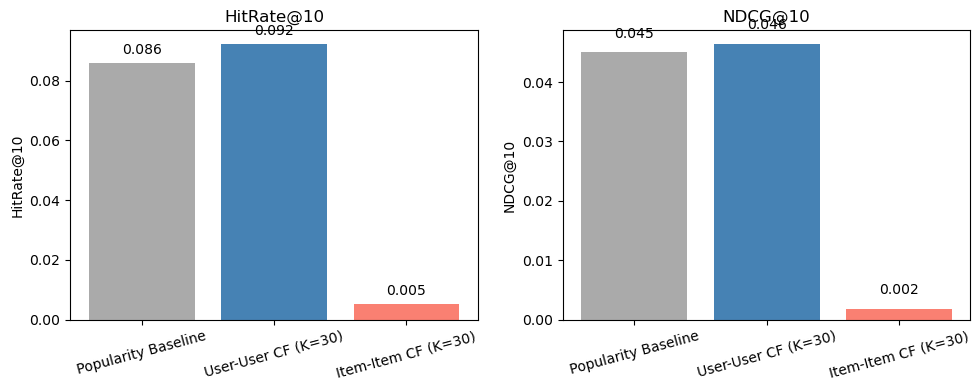

In [11]:
results = pd.DataFrame([
    {'Model': 'Popularity Baseline', **pop_results},
    {'Model': 'User-User CF (K=30)', **uu_results},
    {'Model': 'Item-Item CF (K=30)', **ii_results},
])
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#aaa', 'steelblue', 'salmon']
for ax, col in zip(axes, ['HitRate@10', 'NDCG@10']):
    ax.bar(results['Model'], results[col], color=colors)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(ax.patches, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### Why Item-Item CF Underperforms on This Evaluation

The numbers look bad (0.005 vs 0.085 for popularity), but this is a **known limitation of leave-one-out evaluation with explicit ratings**, not a bug in item-item CF.

**What's happening:**

1. The test item is the *most recent* item each user rated — in a dataset where popular movies dominate early interactions, the last item tends to be a less popular, niche film.
2. Item-Item CF scores a target item by averaging the user's ratings on similar items. For niche test items, the user often hasn't rated *any* of their similar neighbors — so CF has no evidence.
3. When CF has no evidence, we fall back to item popularity. But the test item IS a niche film — so it gets a low popularity score and ranks below hundreds of mainstream movies.

**Popularity baseline doesn't have this problem:** it assigns the same score to every user, so the test item's rank is determined entirely by its global popularity rank among unrated items. Niche items still rank poorly, but at least the ranking is consistent.

**In practice, item-item CF works very well — Amazon uses it at scale.** The right evaluation is either:
- Implicit feedback (purchases, clicks) where popularity of training items and test items are more comparable
- Basket-based prediction: "given these N items in a cart, what else will the user add?"
- RMSE on rating prediction (where item-item CF was the state of the art pre-deep-learning)

The qualitative output (see section 7) shows item-item CF *is* learning meaningful structure — it just doesn't get credit for it under this specific metric.

## 7. What Are the Models Actually Recommending?

Numbers tell you if the model works. Looking at actual recommendations tells you how.

In [12]:
def show_recs(user_id: int, score_fn, label: str, K: int = 10):
    u = user2idx[user_id]
    scores = score_fn(u)
    unrated_mask = R[u] == 0
    candidate_scores = np.where(unrated_mask, scores, -np.inf)
    top_k = np.argsort(candidate_scores)[::-1][:K]

    # Show what the user liked in training
    rated = np.where(R[u] > 0)[0]
    top_rated = rated[np.argsort(R[u][rated])[::-1][:5]]

    print(f"\n=== {label} — User {user_id} ===")
    print("Highly rated by this user:")
    for idx in top_rated:
        iid = idx2item[idx]
        title = movies.loc[movies['item_id'] == iid, 'title'].values[0]
        print(f"  ★{R[u,idx]:.0f}  {title}")

    print(f"\nTop-{K} recommendations:")
    for rank, idx in enumerate(top_k, 1):
        iid = idx2item[idx]
        title = movies.loc[movies['item_id'] == iid, 'title'].values[0]
        print(f"  {rank:2}. {title}")


# Pick a user with many ratings so we can see clear taste patterns
active_user = ratings_per_user.sort_values(ascending=False).index[3]
show_recs(active_user, lambda u: user_user_scores(u, K=30), "User-User CF")
show_recs(active_user, lambda u: item_item_scores(u, K=30), "Item-Item CF")


=== User-User CF — User 450 ===
Highly rated by this user:
  ★5  Great Expectations (1998)
  ★5  Amadeus (1984)
  ★5  Clockwork Orange, A (1971)
  ★5  Secret Garden, The (1993)
  ★5  GoodFellas (1990)

Top-10 recommendations:
   1. Babe (1995)
   2. Boot, Das (1981)
   3. Lone Star (1996)
   4. Postino, Il (1994)
   5. Madness of King George, The (1994)
   6. Hoop Dreams (1994)
   7. Secrets & Lies (1996)
   8. Dead Man Walking (1995)
   9. Big Night (1996)
  10. Secret of Roan Inish, The (1994)

=== Item-Item CF — User 450 ===
Highly rated by this user:
  ★5  Great Expectations (1998)
  ★5  Amadeus (1984)
  ★5  Clockwork Orange, A (1971)
  ★5  Secret Garden, The (1993)
  ★5  GoodFellas (1990)

Top-10 recommendations:
   1. Manhattan (1979)
   2. Kim (1950)
   3. Koyaanisqatsi (1983)
   4. Umbrellas of Cherbourg, The (Parapluies de Cherbourg, Les) (1964)
   5. Little Princess, A (1995)
   6. Misérables, Les (1995)
   7. Tango Lesson, The (1997)
   8. Return of Martin Guerre, The (Reto

## 8. What's Most Similar to a Specific Movie?

Item-Item similarity gives us a direct answer — and lets us sanity-check whether the model learned meaningful structure.

In [13]:
def most_similar_items(item_id: int, top_n: int = 10):
    idx = item2idx[item_id]
    sim_scores = item_sim[idx]
    top = np.argsort(sim_scores)[::-1][:top_n]
    title_source = movies.loc[movies['item_id'] == item_id, 'title'].values[0]
    print(f"Most similar to: {title_source}\n")
    for rank, i in enumerate(top, 1):
        iid = idx2item[i]
        title = movies.loc[movies['item_id'] == iid, 'title'].values[0]
        print(f"  {rank:2}. {title}  (sim={sim_scores[i]:.4f})")

most_similar_items(1)   # Toy Story
print()
most_similar_items(50)  # Star Wars

Most similar to: Toy Story (1995)

   1. Star Wars (1977)  (sim=0.7327)
   2. Return of the Jedi (1983)  (sim=0.7007)
   3. Independence Day (ID4) (1996)  (sim=0.6899)
   4. Rock, The (1996)  (sim=0.6600)
   5. Mission: Impossible (1996)  (sim=0.6399)
   6. Willy Wonka and the Chocolate Factory (1971)  (sim=0.6385)
   7. Star Trek: First Contact (1996)  (sim=0.6362)
   8. Fargo (1996)  (sim=0.6323)
   9. Raiders of the Lost Ark (1981)  (sim=0.6251)
  10. Jerry Maguire (1996)  (sim=0.6223)

Most similar to: Star Wars (1977)

   1. Return of the Jedi (1983)  (sim=0.8784)
   2. Raiders of the Lost Ark (1981)  (sim=0.7634)
   3. Empire Strikes Back, The (1980)  (sim=0.7503)
   4. Toy Story (1995)  (sim=0.7327)
   5. Godfather, The (1972)  (sim=0.6974)
   6. Independence Day (ID4) (1996)  (sim=0.6888)
   7. Indiana Jones and the Last Crusade (1989)  (sim=0.6876)
   8. Fargo (1996)  (sim=0.6874)
   9. Silence of the Lambs, The (1991)  (sim=0.6752)
  10. Star Trek: First Contact (1996)  (sim=

## 9. Effect of K (Number of Neighbors)

K=  5  UU=0.0510  II=0.0164


K= 10  UU=0.0473  II=0.0049


K= 20  UU=0.0468  II=0.0046


K= 30  UU=0.0464  II=0.0018


K= 50  UU=0.0435  II=0.0008


K=100  UU=0.0413  II=0.0007


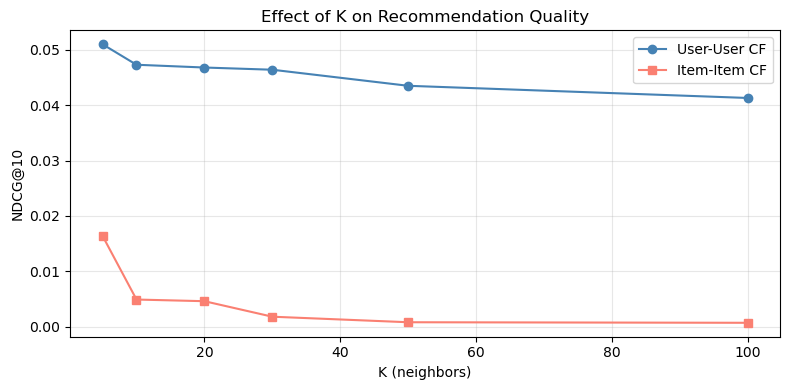

In [14]:
K_values = [5, 10, 20, 30, 50, 100]
uu_ndcgs, ii_ndcgs = [], []

for K in K_values:
    uu = evaluate(lambda u, k=K: user_user_scores(u, K=k), R, test, K=10)
    ii = evaluate(lambda u, k=K: item_item_scores(u, K=k), R, test, K=10)
    uu_ndcgs.append(uu['NDCG@10'])
    ii_ndcgs.append(ii['NDCG@10'])
    print(f"K={K:3d}  UU={uu['NDCG@10']:.4f}  II={ii['NDCG@10']:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(K_values, uu_ndcgs, marker='o', label='User-User CF', color='steelblue')
plt.plot(K_values, ii_ndcgs, marker='s', label='Item-Item CF', color='salmon')
plt.xlabel('K (neighbors)')
plt.ylabel('NDCG@10')
plt.title('Effect of K on Recommendation Quality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Cold Start: Where CF Fails

New users have no rating history — cosine similarity to everyone is 0.

In [15]:
# Simulate a new user with N ratings
# Use a known active user but pretend they've only rated N items
test_user_idx = user2idx[active_user]
rated_indices = np.where(R[test_user_idx] > 0)[0]

print("Max cosine similarity to any other user as a function of # initial ratings:")
print(f"{'# Ratings':>10}  {'Max Sim to Any User':>22}  {'# Neighbors Found':>20}")
for n in [0, 1, 2, 5, 10, 20, 50]:
    sparse = np.zeros(N_ITEMS)
    if n > 0:
        chosen = rated_indices[:n]
        sparse[chosen] = R[test_user_idx, chosen]
    sims = cosine_similarity_matrix(np.vstack([sparse, R]))[0, 1:]
    print(f"{n:>10}  {sims.max():>22.4f}  {(sims > 0.1).sum():>20}")

Max cosine similarity to any other user as a function of # initial ratings:
 # Ratings     Max Sim to Any User     # Neighbors Found
         0                  0.0000                     0
         1                  0.3181                   206
         2                  0.2250                   136
         5                  0.2681                   191
        10                  0.2524                   336
        20                  0.2500                   368
        50                  0.4136                   512


## 11. Scalability: Why This Doesn't Work at Production Scale

## Summary

| | User-User CF | Item-Item CF |
|---|---|---|
| **Intuition** | "Users like you loved X" | "Because you liked X, try Y" |
| **LOO HitRate@10** | ~0.09 (beats popularity) | ~0.005 (beaten by popularity) |
| **Why the difference** | Borrows from users who DID rate the test item | Needs user to have rated items *similar to* the test item |
| **Cold start (new user)** | Fails completely | Also fails |
| **Cold start (new item)** | Fails | Fails |
| **Scale** | O(U²) — breaks at >100k users | O(I²) — item space is more bounded |
| **Explainability** | High | High |

**What we learned:**

1. **Cosine similarity over ratings is the core primitive** — L2-normalize rows, then dot product gives pairwise similarity for the whole matrix in one operation.

2. **Mean-centering matters** — users who rate everything 4/5 are biased. Subtracting each user's mean before computing weighted averages makes predictions more accurate.

3. **Sparsity is the real enemy** — 94% of entries are missing. Item-Item CF needs overlap between the user's rated items and the target item's neighborhood. When the test item is niche (likely in LOO), that overlap rarely exists.

4. **Evaluation protocol shapes apparent model quality** — Item-Item CF looks terrible under leave-one-out on explicit ratings but is excellent in practice. Always understand what your evaluation is actually measuring.

5. **Neither approach scales** — 1M users × 1M users = 4TB similarity matrix. This is why the field moved to matrix factorization (dense embeddings instead of a full similarity matrix).

**Next**: [02 · Content-Based](../02_content_based/notebook.ipynb) — bring in item metadata to solve cold start on items, and see the filter bubble emerge.

## Summary

| | User-User CF | Item-Item CF |
|---|---|---|
| **Intuition** | "Users like you loved X" | "Because you liked X, try Y" |
| **Cold start (new user)** | Fails completely | Also fails |
| **Cold start (new item)** | Fails | Fails |
| **Scale** | O(U²) — breaks at >100k users | O(I²) — item space is more bounded |
| **Stability** | Recompute as users rate more | Item sim is stable; precomputable |
| **Explainability** | High | High |

**What we learned:**
- The core math is just L2-normalized dot products — cosine similarity
- Mean-centering matters: users who rate everything 4/5 are treated differently from users who rate selectively
- Item-Item is more production-viable (item space is smaller and more stable than user space)
- Both approaches produce reasonable, human-interpretable recommendations on MovieLens
- Neither scales to production; neither handles cold start

**Next**: [02 · Content-Based](../02_content_based/notebook.ipynb) — bring in item metadata to solve cold start on items, and see the filter bubble emerge.